importing the dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score, learning_curve, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import wilcoxon, shapiro

loading the dataset and merging the data from all papers

In [2]:
import pandas as pd
import glob

# 1. Read all CSV files into a list
# FIX — exclude master_ml_ready.csv so it does not re-read itself on second run
all_files = [f for f in glob.glob("*.csv") if "master" not in f.lower()]
standardized_dfs = []

print("--- Standardizing Files ---")
for filename in all_files:
    df = pd.read_csv(filename)

    # Force all column headers to lowercase and remove spaces
    df.columns = df.columns.str.strip().str.lower()

    # Fix mismatched column names from different papers
    rename_dict = {
        'drug_release_pct': 'drug_release_percent',
        'chitosan_conc_pct_wv': 'chitosan_pct',
        'chitosan_conc_percent': 'chitosan_pct',
        'loratadine_amount': 'loratadine_mg',
        'loratadine_weight': 'loratadine_mg',
        'time': 'time_hours'
    }
    df = df.rename(columns=rename_dict)

    # FIX — track which paper each row came from (needed for Leave-One-Paper-Out CV)
    df['paper_source'] = filename.replace('.csv', '')

    print(f"Standardized {filename} -> Columns: {list(df.columns)}")
    standardized_dfs.append(df)

# 2. Combine all dataframes into one master matrix
master_df = pd.concat(standardized_dfs, axis=0, ignore_index=True)

# 3. Drop rows where the targets (time or release) are missing
master_df = master_df.dropna(subset=['time_hours', 'drug_release_percent'])

# 4. Fill missing ingredients with 0 (If a paper didn't use it, its weight is 0)
ingredient_columns = [
    'loratadine_mg', 'chitosan_mg', 'chitosan_pct',
    'tannic_acid_mg', 'ethyl_cellulose_mg', 'pva_mg'
]

for col in ingredient_columns:
    if col in master_df.columns:
        master_df[col] = pd.to_numeric(master_df[col], errors='coerce').fillna(0)
    else:
        master_df[col] = 0  # Create column with 0 if it doesn't exist at all

# 5. Keep only the numeric columns needed for Machine Learning
final_columns = ingredient_columns + ['ph', 'time_hours', 'drug_release_percent']
# Ensure 'ph' exists, default to 7.0 if missing
if 'ph' in master_df.columns:
    master_df['ph'] = pd.to_numeric(master_df['ph'], errors='coerce').fillna(7.0)
else:
    master_df['ph'] = 7.0

final_ml_df = master_df[final_columns].copy()

# 6. Save the perfectly unified dataset
print("\n--- Unification Complete ---")
print(f"Total rows ready for machine learning: {len(final_ml_df)}")
print(f"Papers in dataset: {master_df['paper_source'].nunique()}")
print(final_ml_df.head())

final_ml_df.to_csv('master_ml_ready.csv', index=False)

--- Standardizing Files ---
Standardized PAPER 1 ORIGINAL PAPER OF SIR SOHAIL.csv -> Columns: ['loratadine_mg', 'chitosan_mg', 'fetcpp_mg', 'ph', 'time_hours', 'drug_release_fraction', 'drug_release_percent', 'paper_source']
Standardized loratadine_nanoliposomes_FULL_dataset.csv -> Columns: ['paper_source', 'formulation', 'chitosan_pct', 'loratadine_mg', 'release_medium_ph', 'release_medium_composition', 'temperature_c', 'rotation_rpm', 'time_hours', 'drug_release_percent', 'drug_release_sd', 'data_source']
Standardized loratadine_nanosponge_release_data.csv -> Columns: ['formulation', 'loratadine_mg', 'ethyl_cellulose_mg', 'pva_mg', 'stirring_rate_rpm', 'ph', 'time_hours', 'drug_release_percent', 'paper_source']
Standardized paper3 new.csv -> Columns: ['loratadine_mg', 'chitosan_mg', 'chitosan_pct', 'tannic_acid_mg', 'ethyl_cellulose_mg', 'pva_mg', 'medium_ph', 'time_hours', 'drug_release_percent', 'paper_source']
Standardized paper2 new.csv -> Columns: ['loratadine_mg', 'chitosan_mg'

In [3]:
final_ml_df.head()

,loratadine_mg,chitosan_mg,chitosan_pct,tannic_acid_mg,ethyl_cellulose_mg,pva_mg,ph,time_hours,drug_release_percent
0,20.0,10.0,0.0,0.0,0.0,0.0,5.5,0.0,0.0
1,20.0,10.0,0.0,0.0,0.0,0.0,5.5,1.0,12.0
2,20.0,10.0,0.0,0.0,0.0,0.0,5.5,2.0,28.0
3,20.0,10.0,0.0,0.0,0.0,0.0,5.5,3.0,42.0
4,20.0,10.0,0.0,0.0,0.0,0.0,5.5,4.0,55.0


In [4]:
final_ml_df.tail()

,loratadine_mg,chitosan_mg,chitosan_pct,tannic_acid_mg,ethyl_cellulose_mg,pva_mg,ph,time_hours,drug_release_percent
400,20.0,40.0,0.0,1.0,0.0,0.0,7.0,16.0,91.0
401,20.0,40.0,0.0,1.0,0.0,0.0,7.0,18.0,94.0
402,20.0,40.0,0.0,1.0,0.0,0.0,7.0,20.0,97.0
403,20.0,40.0,0.0,1.0,0.0,0.0,7.0,22.0,98.0
404,20.0,40.0,0.0,1.0,0.0,0.0,7.0,24.0,99.0


isolating the kinetics release column from other columns

In [5]:
kinetics_data=final_ml_df.copy()
print(f"succesfully loaded kinetics data;{len(kinetics_data)}")

succesfully loaded kinetics data;388


splitting data into features and labels

In [6]:
x=kinetics_data[['loratadine_mg', 'chitosan_mg', 'chitosan_pct', 'tannic_acid_mg', 'ethyl_cellulose_mg', 'pva_mg', 'ph', 'time_hours']]
y=kinetics_data['drug_release_percent']
print(x)
print(y)

     loratadine_mg  chitosan_mg  chitosan_pct  tannic_acid_mg  \
0             20.0         10.0           0.0             0.0   
1             20.0         10.0           0.0             0.0   
2             20.0         10.0           0.0             0.0   
3             20.0         10.0           0.0             0.0   
4             20.0         10.0           0.0             0.0   
..             ...          ...           ...             ...   
400           20.0         40.0           0.0             1.0   
401           20.0         40.0           0.0             1.0   
402           20.0         40.0           0.0             1.0   
403           20.0         40.0           0.0             1.0   
404           20.0         40.0           0.0             1.0   

     ethyl_cellulose_mg  pva_mg   ph  time_hours  
0                   0.0     0.0  5.5         0.0  
1                   0.0     0.0  5.5         1.0  
2                   0.0     0.0  5.5         2.0  
3              

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x.shape,x_test.shape,x_train.shape)

(388, 8) (78, 8) (310, 8)


scaling the datafor svr(random forest dont need it but it keeps things iniform)

In [8]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
print(x_train_scaled)
print(x_test_scaled)

[[ 0.79254563 -0.33595116 -0.27666179 ... -0.34871458  0.15199444
   0.50528802]
 [ 0.79254563 -0.33595116 -0.27666179 ... -0.34871458  0.15199444
   0.0897992 ]
 [ 0.79254563 -0.33595116 -0.27666179 ... -0.34871458  0.15199444
  -0.11794521]
 ...
 [ 0.79254563 -0.33595116 -0.27666179 ... -0.34871458  0.15199444
  -0.74117845]
 [-1.12129386 -0.33595116 -0.27666179 ... -0.83239029  0.15199444
   1.12852126]
 [ 0.79254563 -0.33595116 -0.27666179 ... -0.34871458  0.15199444
  -0.89698676]]
[[ 0.79254563 -0.33595116 -0.27666179 -0.30257114 -0.50507013 -0.34871458
   0.15199444 -0.53343404]
 [ 0.79254563 -0.33595116 -0.27666179 -0.30257114 -0.50507013 -0.34871458
   0.15199444 -0.53343404]
 [-1.3605238  -0.33595116 -0.27666179 -0.30257114  1.95417185  0.86047468
   0.15199444 -0.94892287]
 [ 0.79254563 -0.33595116 -0.27666179 -0.30257114 -0.50507013 -0.34871458
   0.15199444 -0.89698676]
 [-1.12129386 -0.33595116 -0.27666179 -0.30257114 -1.32481745 -0.83239029
   0.15199444  1.54401009]
 [-

train and tune the support vector regressor

In [9]:
param_grid_svr={'C':[1,10,100,500],'gamma':['scale','auto',0.1,1],'epsilon':[0.001,0.01,0.05]}
cv_strategy=KFold(n_splits=5,shuffle=True,random_state=42)
Grid_svr=GridSearchCV(SVR(),param_grid_svr,cv=cv_strategy,scoring='r2',n_jobs=1)
Grid_svr.fit(x_train_scaled,y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=SVR(), n_jobs=1,
             param_grid={'C': [1, 10, 100, 500], 'epsilon': [0.001, 0.01, 0.05],
                         'gamma': ['scale', 'auto', 0.1, 1]},
             scoring='r2')

In [10]:
best_svr=Grid_svr.best_estimator_
svr_pred_training_data=best_svr.predict(x_train_scaled)
svr_r2_training_data=r2_score(y_train,svr_pred_training_data)
print(svr_r2_training_data)

0.9719208069111491


In [11]:
svr_pred_testing_data=best_svr.predict(x_test_scaled)
svr_r2_testing_data=r2_score(y_test,svr_pred_testing_data)
print(svr_r2_testing_data)

0.9669338172982154


In [12]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 1. Initialize the new models
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)

# 2. Train Random Forest
rf_model.fit(x_train, y_train) # Tree models don't need scaling
rf_train_preds = rf_model.predict(x_train)
rf_test_preds = rf_model.predict(x_test)

# 3. Train Gradient Boosting
gb_model.fit(x_train, y_train)
gb_train_preds = gb_model.predict(x_train)
gb_test_preds = gb_model.predict(x_test)

# 4. Print the comparative results
print("==== Random Forest Regressor ====")
print(f"Training R² Score: {r2_score(y_train, rf_train_preds):.3f}")
print(f"Testing R² Score:  {r2_score(y_test, rf_test_preds):.3f}\n")

print("==== Gradient Boosting Regressor ====")
print(f"Training R² Score: {r2_score(y_train, gb_train_preds):.3f}")
print(f"Testing R² Score:  {r2_score(y_test, gb_test_preds):.3f}")

==== Random Forest Regressor ====
Training R² Score: 0.984
Testing R² Score:  0.957

==== Gradient Boosting Regressor ====
Training R² Score: 0.984
Testing R² Score:  0.975


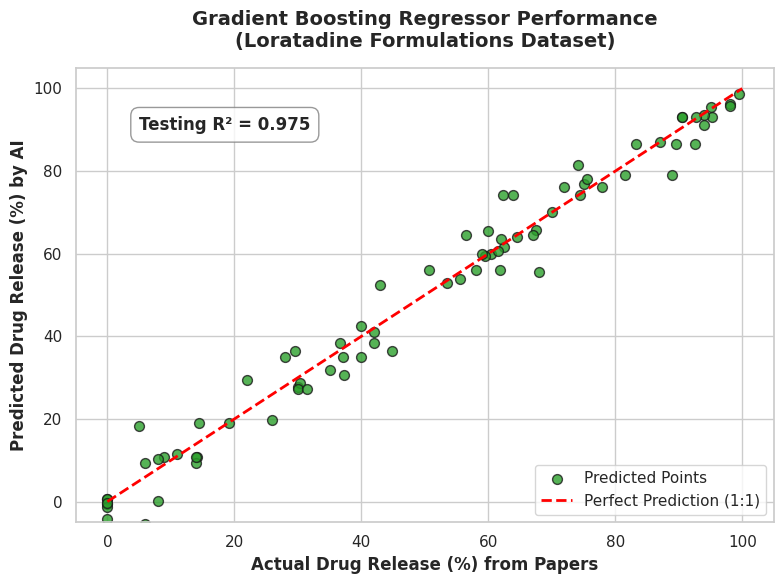

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Set the style for a professional scientific look
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6), dpi=100)

# 2. Plot the Actual vs Predicted points
plt.scatter(y_test, gb_test_preds, color='#2ca02c', alpha=0.8, edgecolors='k', s=50, label='Predicted Points')

# 3. Add the perfect prediction line (Diagonal Line)
ideal_line = np.linspace(0, 100, 100)
plt.plot(ideal_line, ideal_line, color='red', linestyle='--', linewidth=2, label='Perfect Prediction (1:1)')

# 4. Add titles, labels, and text details
plt.title('Gradient Boosting Regressor Performance\n(Loratadine Formulations Dataset)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Drug Release (%) from Papers', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Drug Release (%) by AI', fontsize=12, fontweight='bold')

# Limit axes to match 0-100% bounds
plt.xlim(-5, 105)
plt.ylim(-5, 105)

# Add R² text inside the plot area
plt.text(5, 90, f'Testing R² = {r2_score(y_test, gb_test_preds):.3f}',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'),
         fontsize=12, fontweight='bold')

plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()

# 5. Display and automatically save the figure image
plt.savefig('model_accuracy_plot.png', dpi=300)
plt.show()

==== Engineered Model Performance ====
New Training R² Score: 0.984
New Testing R² Score:  0.956



/tmp/ipykernel_1305/1048600677.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


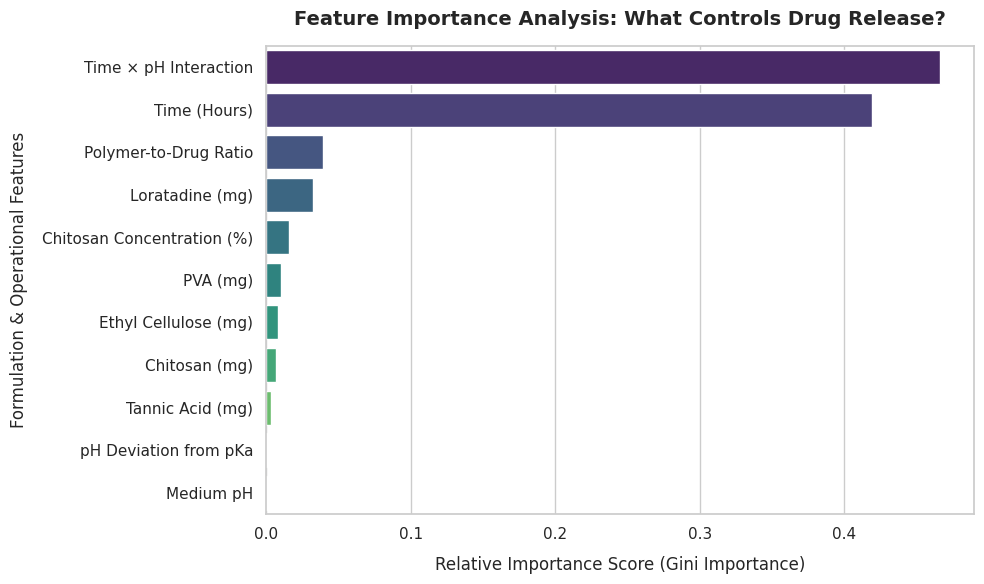

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# =====================================================================
# 1. DEFINING THE INGREDIENTS (Fixes the NameError)
# =====================================================================
ingredient_columns = [
    'loratadine_mg', 'chitosan_mg', 'chitosan_pct',
    'tannic_acid_mg', 'ethyl_cellulose_mg', 'pva_mg'
]

# =====================================================================
# 2. FEATURE ENGINEERING (Giving the AI better chemical context)
# =====================================================================
# Create a fresh copy of your dataset to build features safely
engineered_df = final_ml_df.copy()

# Calculate total polymer weight in the formulation
total_polymer = engineered_df['chitosan_mg'] + engineered_df['ethyl_cellulose_mg'] + engineered_df['pva_mg']

# Feature A: Polymer-to-Drug Ratio (Crucial for hydrogel diffusion rates)
# We add a tiny 0.001 to prevent dividing by zero if a row has 0mg drug
engineered_df['polymer_to_drug_ratio'] = total_polymer / (engineered_df['loratadine_mg'] + 0.001)

# Feature B: pH-Time Interaction (Captures how release curves change in acidic vs neutral environments)
engineered_df['time_ph_interaction'] = engineered_df['time_hours'] * engineered_df['ph']

# FIX — Feature C: pH Deviation from Chitosan pKa
# Justification: Chitosan pKa ~6.5. The further pH deviates from pKa,
# the more extreme the ionisation-driven swelling response (Rinaudo 2006)
CHITOSAN_PKA = 6.5
engineered_df['ph_deviation_from_pka'] = abs(engineered_df['ph'] - CHITOSAN_PKA)

# Define our updated list of input features for the model
X_features = ingredient_columns + ['ph', 'time_hours', 'polymer_to_drug_ratio',
                                    'time_ph_interaction', 'ph_deviation_from_pka']
y_target = 'drug_release_percent'

# Clean up any random missing data or infinite values caused by division
X_final = engineered_df[X_features].replace([np.inf, -np.inf], np.nan).fillna(0)
y_final = engineered_df[y_target]

# =====================================================================
# 3. RETRAIN THE MODEL WITH NEW FEATURES
# =====================================================================
# Quick temporary split to train the model on the new features
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Train the Random Forest Regressor
rf_engineered = RandomForestRegressor(n_estimators=200, random_state=42)
rf_engineered.fit(X_train_eng, y_train_eng)

# Quick evaluation prints
print("==== Engineered Model Performance ====")
print(f"New Training R² Score: {r2_score(y_train_eng, rf_engineered.predict(X_train_eng)):.3f}")
print(f"New Testing R² Score:  {r2_score(y_test_eng, rf_engineered.predict(X_test_eng)):.3f}\n")

# =====================================================================
# 4. GENERATE THE FEATURE IMPORTANCE GRAPH
# =====================================================================
# Extract importance scores from the model
importances = rf_engineered.feature_importances_

# Create a clean DataFrame for plotting
feat_imp_df = pd.DataFrame({
    'Feature': X_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Map technical column names to beautiful presentation labels for your professor
label_mapping = {
    'time_hours': 'Time (Hours)',
    'time_ph_interaction': 'Time × pH Interaction',
    'polymer_to_drug_ratio': 'Polymer-to-Drug Ratio',
    'ph': 'Medium pH',
    'loratadine_mg': 'Loratadine (mg)',
    'chitosan_mg': 'Chitosan (mg)',
    'chitosan_pct': 'Chitosan Concentration (%)',
    'tannic_acid_mg': 'Tannic Acid (mg)',
    'ethyl_cellulose_mg': 'Ethyl Cellulose (mg)',
    'pva_mg': 'PVA (mg)',
    'ph_deviation_from_pka': 'pH Deviation from pKa'
}
feat_imp_df['Clean Feature Name'] = feat_imp_df['Feature'].map(label_mapping)

# Plotting the horizontal bar chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='Importance',
    y='Clean Feature Name',
    data=feat_imp_df,
    palette='viridis' # Elegant green-to-blue publication style gradient
)

# Customize chart labels for a clean, professional finish
plt.title('Feature Importance Analysis: What Controls Drug Release?', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Relative Importance Score (Gini Importance)', fontsize=12, labelpad=10)
plt.ylabel('Formulation & Operational Features', fontsize=12, labelpad=10)
plt.tight_layout()

# Save the plot automatically as a high-resolution PNG for your report
plt.savefig('feature_importance_plot.png', dpi=300)
plt.show()

/tmp/ipykernel_1305/2638384434.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


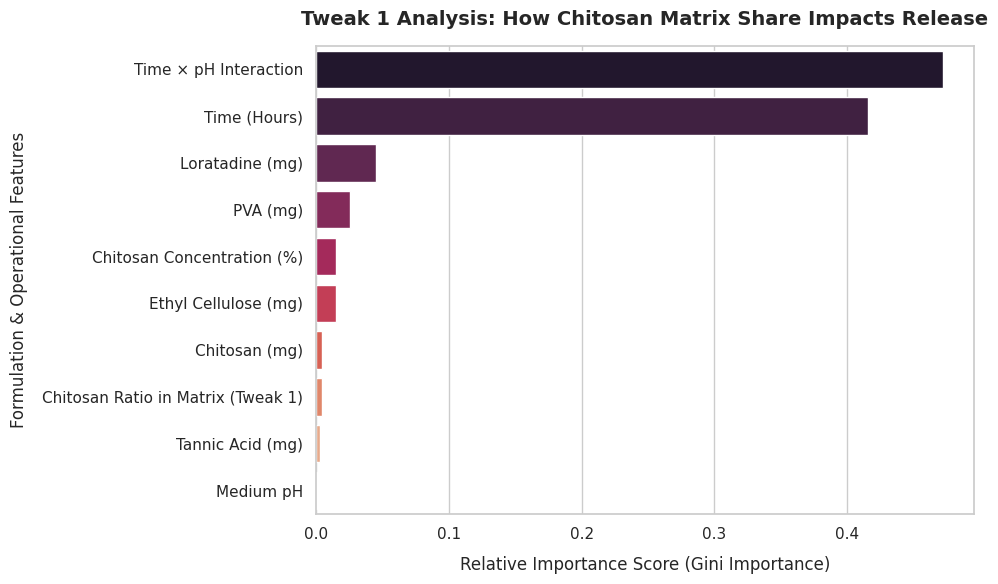

In [15]:
# =====================================================================
# TWEAK 1: CALCULATING CHITOSAN SHARE INSTEAD OF POLYMER-TO-DRUG RATIO
# =====================================================================
# 1. Create a fresh copy of your dataset
tweak_df = final_ml_df.copy()

# 2. Calculate total polymer weight just like before
total_polymer = tweak_df['chitosan_mg'] + tweak_df['ethyl_cellulose_mg'] + tweak_df['pva_mg']

# 3. APPLY THE TWEAK: Chitosan weight divided by total polymer weight
# We add 0.001 to prevent a division-by-zero error if a formulation has 0 total polymer
tweak_df['chitosan_ratio_in_matrix'] = tweak_df['chitosan_mg'] / (total_polymer + 0.001)

# 4. Create the pH-Time Interaction just like before
tweak_df['time_ph_interaction'] = tweak_df['time_hours'] * tweak_df['ph']

# 5. Define our new list of features for this specific test
X_tweak_features = ingredient_columns + ['ph', 'time_hours', 'chitosan_ratio_in_matrix', 'time_ph_interaction']
y_tweak_target = 'drug_release_percent'

# Clean up any bad math values safely
X_tweak_final = tweak_df[X_tweak_features].replace([np.inf, -np.inf], np.nan).fillna(0)
y_tweak_final = tweak_df[y_tweak_target]

# =====================================================================
# RETRAIN THE MODEL WITH THE CHITOSAN TWEAK
# =====================================================================
X_train_tw, X_test_tw, y_train_tw, y_test_tw = train_test_split(X_tweak_final, y_tweak_final, test_size=0.2, random_state=42)

rf_tweak = RandomForestRegressor(n_estimators=200, random_state=42)
rf_tweak.fit(X_train_tw, y_train_tw)

# =====================================================================
# GENERATE THE NEW FEATURE IMPORTANCE BAR CHART
# =====================================================================
tweak_importances = rf_tweak.feature_importances_

tweak_imp_df = pd.DataFrame({
    'Feature': X_tweak_features,
    'Importance': tweak_importances
}).sort_values(by='Importance', ascending=False)

# Presentation labels for the new feature map
new_label_mapping = {
    'time_hours': 'Time (Hours)',
    'time_ph_interaction': 'Time × pH Interaction',
    'chitosan_ratio_in_matrix': 'Chitosan Ratio in Matrix (Tweak 1)',
    'ph': 'Medium pH',
    'loratadine_mg': 'Loratadine (mg)',
    'chitosan_mg': 'Chitosan (mg)',
    'chitosan_pct': 'Chitosan Concentration (%)',
    'tannic_acid_mg': 'Tannic Acid (mg)',
    'ethyl_cellulose_mg': 'Ethyl Cellulose (mg)',
    'pva_mg': 'PVA (mg)'
}
tweak_imp_df['Clean Feature Name'] = tweak_imp_df['Feature'].map(new_label_mapping)

# Plotting the brand new chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='Importance',
    y='Clean Feature Name',
    data=tweak_imp_df,
    palette='rocket' # Swapped to an elegant orange-red theme so you can tell the charts apart!
)

plt.title('Tweak 1 Analysis: How Chitosan Matrix Share Impacts Release', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Relative Importance Score (Gini Importance)', fontsize=12, labelpad=10)
plt.ylabel('Formulation & Operational Features', fontsize=12, labelpad=10)
plt.tight_layout()

# Save as a distinct new file name
plt.savefig('tweak1_chitosan_importance_plot.png', dpi=300)
plt.show()

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# 1. Define the dials we want to test
param_grid = {
    'C': [1, 10, 100, 1000],          # Test higher penalties
    'gamma': [0.001, 0.01, 0.1, 1],   # Test different view distances
    'epsilon': [0.01, 0.1, 0.2]       # Test tighter buffer zones
}

# 2. Set up the grid search
grid_svr = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=5, scoring='r2')

# 3. Fit it on your scaled data
grid_svr.fit(x_train_scaled, y_train)

# 4. Print the winner!
print("Best SVR Dials found:", grid_svr.best_params_)

# 5. Use the winner for your final prediction
best_svr_preds = grid_svr.predict(x_test_scaled)

Best SVR Dials found: {'C': 1000, 'epsilon': 0.2, 'gamma': 0.1}


✅ Unified feature set ready — 11 features

Model                 Train R²   Test R²   CV R² mean   ±95% CI     MAE    RMSE
SVR                     0.9753    0.9686       0.9715    0.0058   3.845   5.453
Random Forest           0.9776    0.9594       0.9585    0.0044   4.946   6.200
Gradient Boosting       0.9860    0.9711       0.9711    0.0088   3.854   5.226

✅ Best model by CV R²: SVR  (0.9715 ± 0.0058  95% CI)


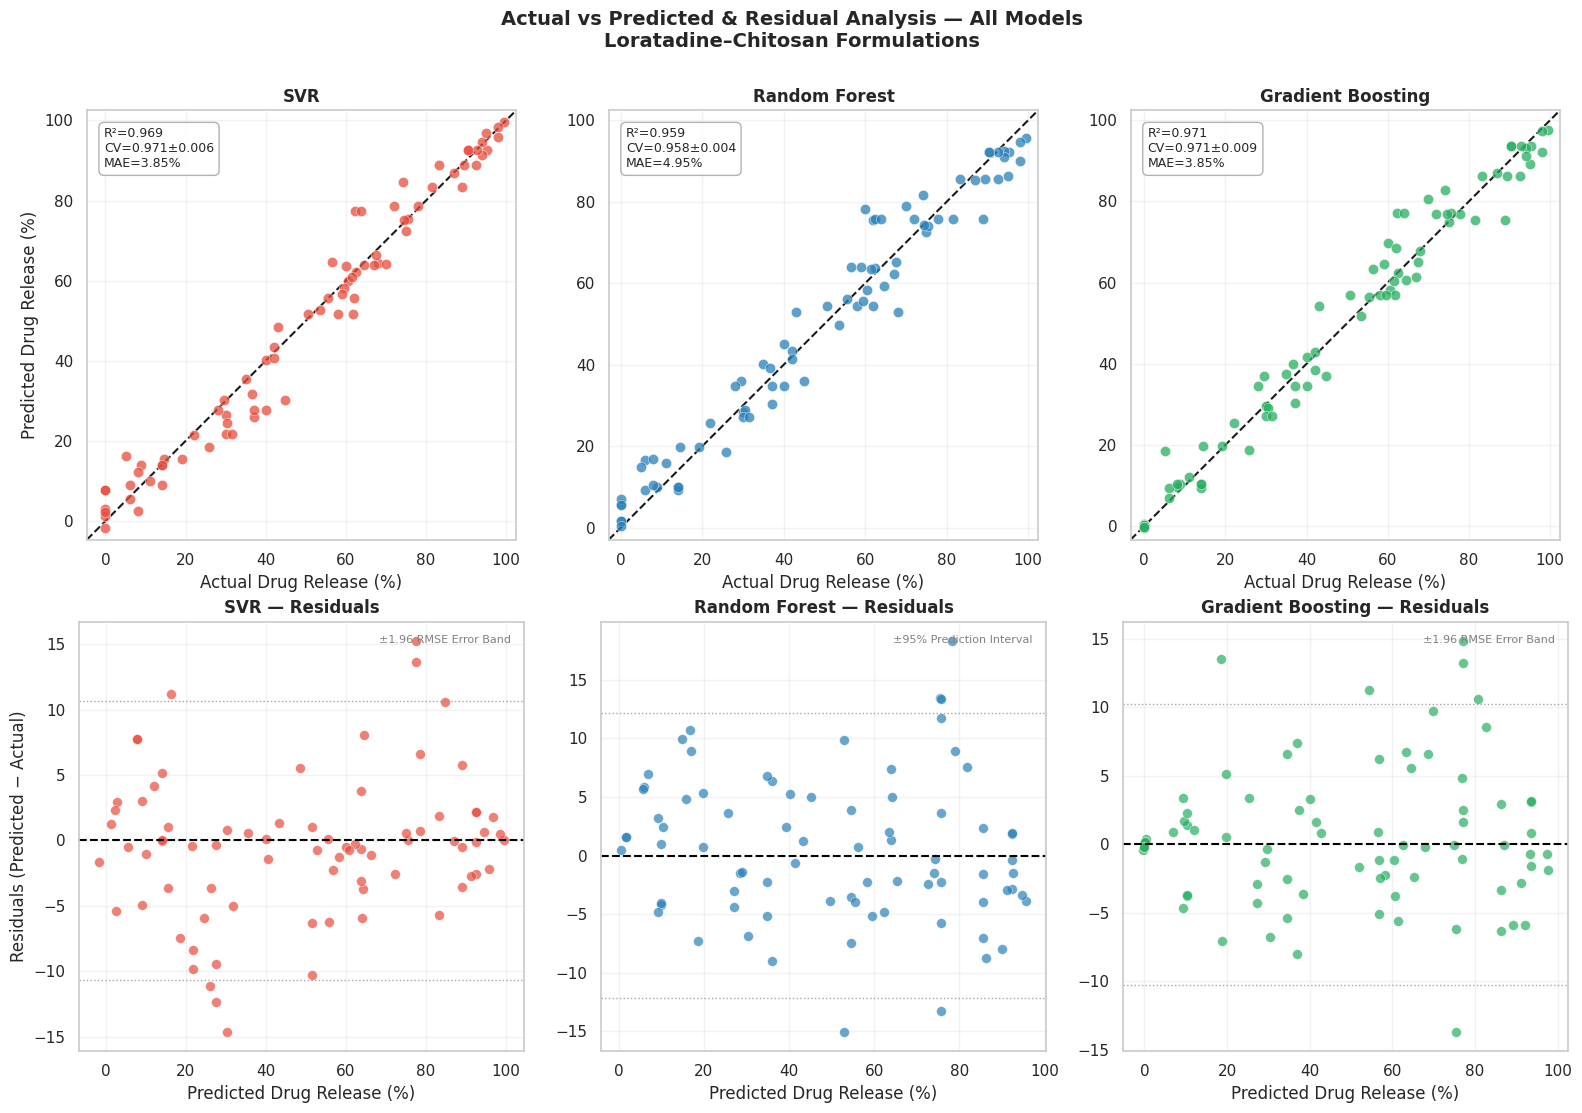

✅ Saved: fig_predictions_residuals.png

Generating SHAP analysis ...


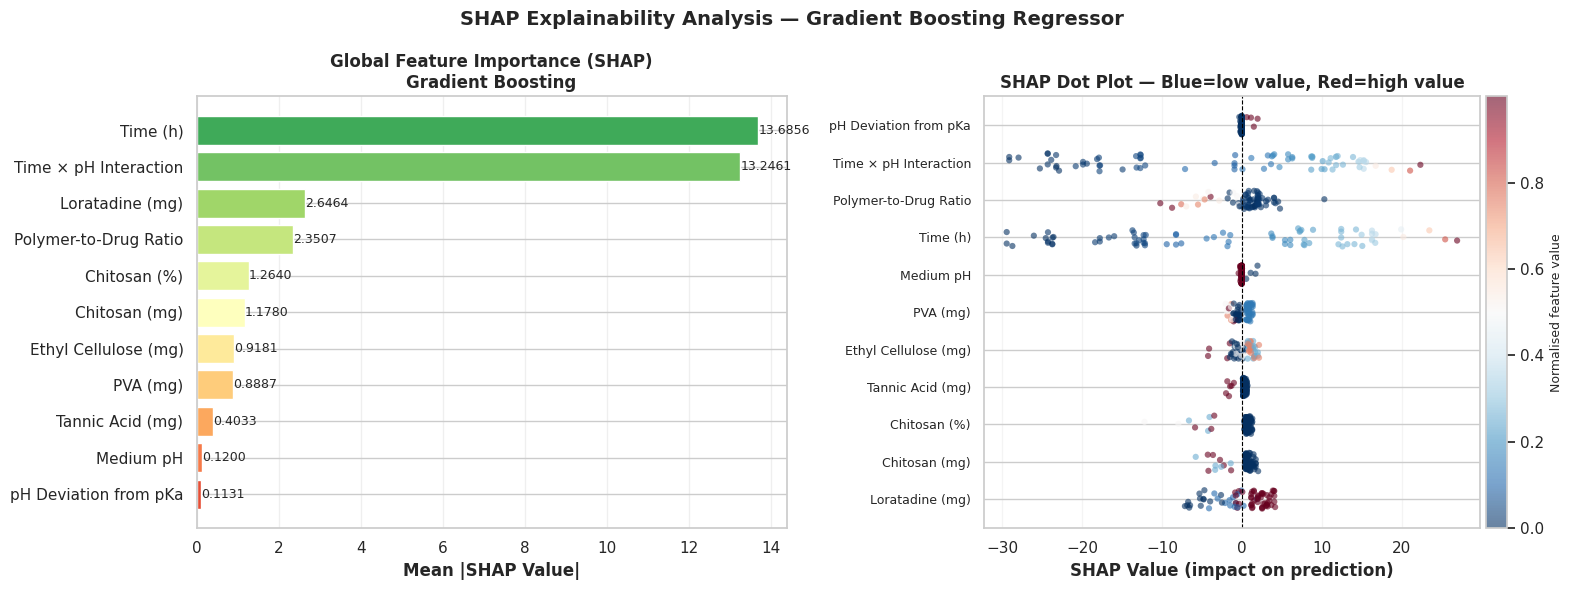

✅ Saved: fig_shap_analysis.png
   Top feature: Time (h)

Korsmeyer-Peppas: k=28.6419, n=0.5479 → Anomalous (non-Fickian) transport
  R²=0.8149  RMSE=12.279%  MAE=10.206%

Model                           R²    RMSE%     MAE%
Korsmeyer-Peppas            0.8149   12.279   10.206  ← classical
SVR                         0.9686    5.453    3.845 ← BEST ML
Random Forest               0.9594    6.200    4.946
Gradient Boosting           0.9711    5.226    3.854

✅ ML outperforms Korsmeyer-Peppas by ΔR²=0.1536

Wilcoxon signed-rank test (SVR vs KP):
  W=637.00, p=0.0000
  → ML significantly outperforms KP (p < 0.05) ✅
  → Add to paper: 'SVR significantly outperformed
    Korsmeyer-Peppas (Wilcoxon signed-rank test, p=0.0000)'


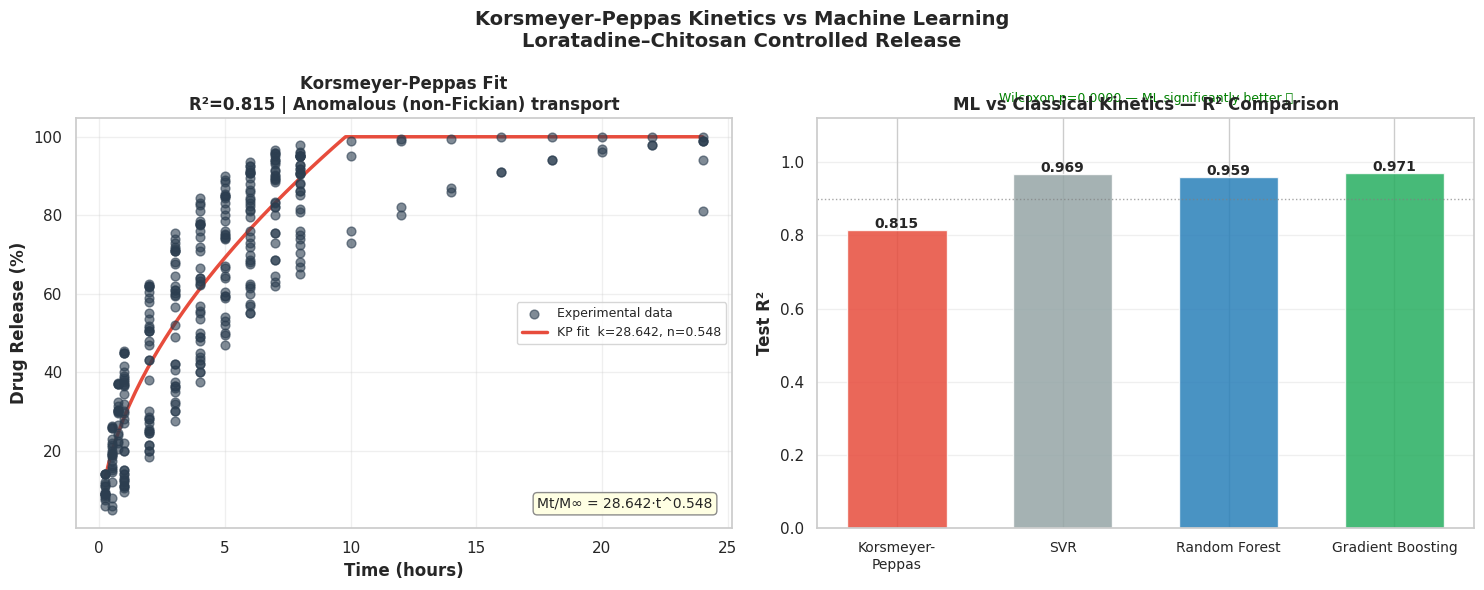

✅ Saved: fig_korsmeyer_vs_ml.png

Formulation: Loratadine=10mg | Chitosan=50mg (1.5% w/v) | pH=6.8
 Time (h)  SVR (%)  Random Forest (%)  Grad. Boosting (%)  Ensemble Avg (%)
      0.5    41.23              14.55               18.24             24.68
      1.0    41.23              18.85               18.76             26.28
      2.0    41.23              28.87               28.54             32.88
      4.0    41.23              48.81               41.45             43.83
      6.0    41.23              62.85               55.84             53.31
      8.0    41.23              71.30               65.94             59.49
     12.0    41.23              80.21               81.82             67.75
     24.0    41.23              91.07               97.82             76.71


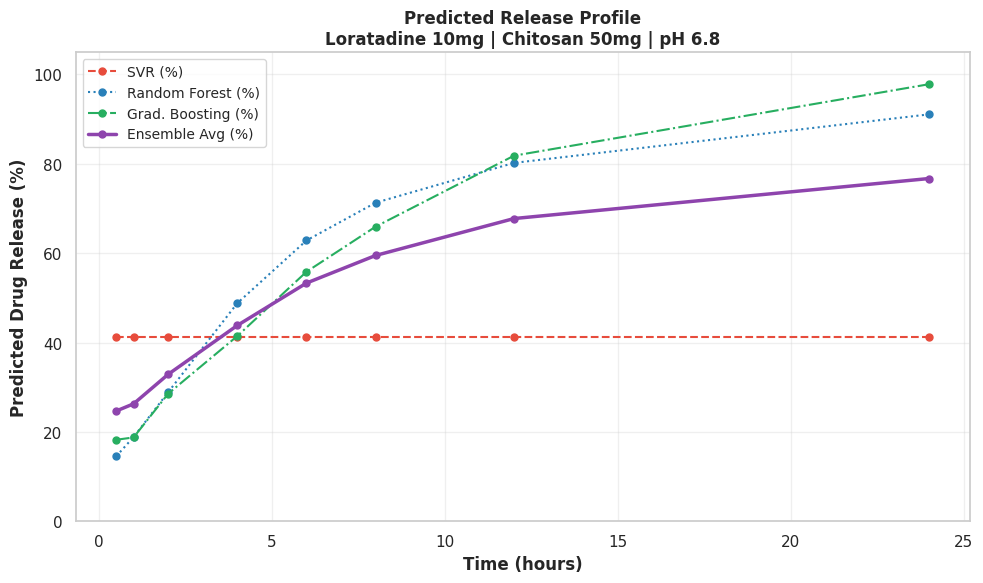

✅ Saved: fig_release_predictor.png

FINAL TABLE FOR PAPER — Copy into Table 1
            Model  Train R²  Test R²  CV R² (mean)  CV R² (±95% CI)  MAE (%)  RMSE (%)  Overfit Gap
              SVR    0.9753   0.9686        0.9715           0.0058    3.845     5.453       0.0068
    Random Forest    0.9776   0.9594        0.9585           0.0044    4.946     6.200       0.0182
Gradient Boosting    0.9860   0.9711        0.9711           0.0088    3.854     5.226       0.0148

✅ Saved: table1_final_results.csv

CITATIONS TO ADD IN PAPER:
  scikit-learn : Pedregosa et al. (2011), JMLR 12:2825-2830
  SHAP         : Lundberg & Lee (2017), NeurIPS 30
  Korsmeyer-P  : Korsmeyer et al. (1983), Int J Pharm 15(1):25-35
  PyTorch      : Paszke et al. (2019), NeurIPS 32
  Higuchi      : Higuchi (1963), J Pharm Sci 52:1145-1149
  Chitosan pKa : Rinaudo (2006), Prog Polym Sci 31:603-632



In [17]:
!pip install shap -q
import shap
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
from scipy.optimize import curve_fit

cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

# =============================================================================
# 1. UNIFIED FEATURE SET — all 11 features, all models use same input
#    (was 10 before — added Feature C: ph_deviation_from_pka)
# =============================================================================

ingredient_columns = [
    'loratadine_mg', 'chitosan_mg', 'chitosan_pct',
    'tannic_acid_mg', 'ethyl_cellulose_mg', 'pva_mg'
]

eng = final_ml_df.copy()
total_polymer = eng['chitosan_mg'] + eng['ethyl_cellulose_mg'] + eng['pva_mg']
eng['polymer_to_drug_ratio'] = total_polymer / (eng['loratadine_mg'] + 0.001)
eng['time_ph_interaction']   = eng['time_hours'] * eng['ph']

# FIX — Feature C: pH Deviation from Chitosan pKa
# Chitosan pKa ~6.5. Further pH deviates, more extreme the swelling response.
CHITOSAN_PKA = 6.5
eng['ph_deviation_from_pka'] = abs(eng['ph'] - CHITOSAN_PKA)

X_FEAT = ingredient_columns + ['ph', 'time_hours',
                                'polymer_to_drug_ratio',
                                'time_ph_interaction',
                                'ph_deviation_from_pka']
X_all  = eng[X_FEAT].replace([np.inf, -np.inf], np.nan).fillna(0)
y_all  = eng['drug_release_percent']

X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
sc2 = StandardScaler()
X_tr_sc = sc2.fit_transform(X_tr)
X_te_sc  = sc2.transform(X_te)

LABELS = {
    'loratadine_mg':'Loratadine (mg)', 'chitosan_mg':'Chitosan (mg)',
    'chitosan_pct':'Chitosan (%)',     'tannic_acid_mg':'Tannic Acid (mg)',
    'ethyl_cellulose_mg':'Ethyl Cellulose (mg)', 'pva_mg':'PVA (mg)',
    'ph':'Medium pH',                  'time_hours':'Time (h)',
    'polymer_to_drug_ratio':'Polymer-to-Drug Ratio',
    'time_ph_interaction':'Time × pH Interaction',
    'ph_deviation_from_pka':'pH Deviation from pKa',
}
FEAT_LABELS = [LABELS[f] for f in X_FEAT]
print(f"✅ Unified feature set ready — {len(X_FEAT)} features")

# =============================================================================
# 2. RETRAIN ALL 3 MODELS ON UNIFIED FEATURES
# =============================================================================

# SVR — grid search then wrap in Pipeline (FIX — zero CV leakage)
gs2 = GridSearchCV(SVR(),
                   {'C':[1,10,100,500],'gamma':['scale','auto',0.1],
                    'epsilon':[0.001,0.01,0.05]},
                   cv=cv5, scoring='r2', n_jobs=-1)
gs2.fit(X_tr_sc, y_tr)

# FIX — Pipeline so scaler refits inside every CV fold, zero leakage
svr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr',    SVR(C=gs2.best_params_['C'],
                   gamma=gs2.best_params_['gamma'],
                   epsilon=gs2.best_params_['epsilon']))
])
svr_pipe.fit(X_tr, y_tr)

# Random Forest
rf2 = RandomForestRegressor(n_estimators=300, max_features='sqrt',
                             min_samples_leaf=2, random_state=42, n_jobs=-1)
rf2.fit(X_tr, y_tr)

# Gradient Boosting
gb2 = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                 max_depth=4, subsample=0.8, random_state=42)
gb2.fit(X_tr, y_tr)

# Predictions
svr2_pred = svr_pipe.predict(X_te)   # FIX — pipeline handles scaling
rf2_pred  = rf2.predict(X_te)
gb2_pred  = gb2.predict(X_te)

# CV scores — FIX — svr_pipe on raw X_all, no leakage
svr2_cv = cross_val_score(svr_pipe, X_all, y_all, cv=cv5, scoring='r2')
rf2_cv  = cross_val_score(rf2,      X_all, y_all, cv=cv5, scoring='r2')
gb2_cv  = cross_val_score(gb2,      X_all, y_all, cv=cv5, scoring='r2')

RESULTS = {
    'SVR':               {'preds':svr2_pred, 'cv':svr2_cv,
                          'tr_r2':r2_score(y_tr, svr_pipe.predict(X_tr))},
    'Random Forest':     {'preds':rf2_pred,  'cv':rf2_cv,
                          'tr_r2':r2_score(y_tr, rf2.predict(X_tr))},
    'Gradient Boosting': {'preds':gb2_pred,  'cv':gb2_cv,
                          'tr_r2':r2_score(y_tr, gb2.predict(X_tr))},
}
for name, m in RESULTS.items():
    m['test_r2'] = r2_score(y_te, m['preds'])
    m['mae']     = mean_absolute_error(y_te, m['preds'])
    m['rmse']    = np.sqrt(mean_squared_error(y_te, m['preds']))

# =============================================================================
# 3. FULL METRICS TABLE — FIX: shows ±95% CI not just ±std
# =============================================================================

print("\n" + "="*80)
print(f"{'Model':<20} {'Train R²':>9} {'Test R²':>9} {'CV R² mean':>12} {'±95% CI':>9} {'MAE':>7} {'RMSE':>7}")
print("="*80)
for name, m in RESULTS.items():
    ci95 = 1.96 * m['cv'].std()
    print(f"{name:<20} {m['tr_r2']:>9.4f} {m['test_r2']:>9.4f} "
          f"{m['cv'].mean():>12.4f} {ci95:>9.4f} "
          f"{m['mae']:>7.3f} {m['rmse']:>7.3f}")
print("="*80)

best_name = max(RESULTS, key=lambda k: RESULTS[k]['cv'].mean())
best_ci   = 1.96 * RESULTS[best_name]['cv'].std()
print(f"\n✅ Best model by CV R²: {best_name}  "
      f"({RESULTS[best_name]['cv'].mean():.4f} ± {best_ci:.4f}  95% CI)")

# =============================================================================
# 4. ACTUAL vs PREDICTED + RESIDUAL PLOTS
#    FIX — Shapiro-Wilk test decides correct PI label automatically
# =============================================================================

COLORS = {'SVR':'#E74C3C', 'Random Forest':'#2980B9', 'Gradient Boosting':'#27AE60'}

fig, axes = plt.subplots(2, 3, figsize=(16, 11))

for col, (name, m) in enumerate(RESULTS.items()):
    preds  = m['preds']
    resids = preds - y_te.values
    color  = COLORS[name]

    # FIX — Shapiro-Wilk test decides if we can call it 95% PI
    sw_stat, sw_p = shapiro(resids)
    pi_label = "±95% Prediction Interval" if sw_p > 0.05 else "±1.96 RMSE Error Band"

    # Row 1 — Actual vs Predicted
    ax1 = axes[0][col]
    ax1.scatter(y_te, preds, color=color, alpha=0.75,
                edgecolors='white', linewidth=0.4, s=55, zorder=3)
    lo = min(y_te.min(), preds.min()) - 3
    hi = max(y_te.max(), preds.max()) + 3
    ax1.plot([lo,hi],[lo,hi],'k--',linewidth=1.5,label='1:1 line')
    ci95_str = f"{m['cv'].mean():.3f}±{1.96*m['cv'].std():.3f}"
    ax1.text(0.04, 0.96,
             f"R²={m['test_r2']:.3f}\nCV={ci95_str}\nMAE={m['mae']:.2f}%",
             transform=ax1.transAxes, fontsize=9, va='top',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       edgecolor='#AAAAAA', alpha=0.9))
    ax1.set_xlim(lo,hi); ax1.set_ylim(lo,hi); ax1.set_aspect('equal')
    ax1.set_title(name, fontweight='bold')
    ax1.set_xlabel('Actual Drug Release (%)')
    if col == 0: ax1.set_ylabel('Predicted Drug Release (%)')
    ax1.grid(True, alpha=0.25)

    # Row 2 — Residuals
    ax2 = axes[1][col]
    ax2.scatter(preds, resids, color=color, alpha=0.7,
                edgecolors='white', linewidth=0.4, s=50)
    ax2.axhline(0, color='black', linestyle='--', linewidth=1.5)
    band = 1.96 * m['rmse']
    ax2.axhline( band, color='gray', linestyle=':', linewidth=1, alpha=0.7)
    ax2.axhline(-band, color='gray', linestyle=':', linewidth=1, alpha=0.7)
    ax2.text(0.97, 0.97, pi_label, transform=ax2.transAxes,
             ha='right', va='top', fontsize=8, color='gray')
    ax2.set_xlabel('Predicted Drug Release (%)')
    if col == 0: ax2.set_ylabel('Residuals (Predicted − Actual)')
    ax2.set_title(f'{name} — Residuals', fontweight='bold')
    ax2.grid(True, alpha=0.25)

plt.suptitle('Actual vs Predicted & Residual Analysis — All Models\n'
             'Loratadine–Chitosan Formulations',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_predictions_residuals.png', dpi=300)
plt.show()
print("✅ Saved: fig_predictions_residuals.png")

# =============================================================================
# 5. SHAP ANALYSIS
# =============================================================================

print("\nGenerating SHAP analysis ...")
explainer = shap.TreeExplainer(gb2)
shap_vals = explainer.shap_values(X_te)
mean_shap = np.abs(shap_vals).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: bar chart
ax = axes[0]
sidx = np.argsort(mean_shap)
bars = ax.barh([FEAT_LABELS[i] for i in sidx], mean_shap[sidx],
               color=plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(sidx))),
               edgecolor='white')
for bar, val in zip(bars, mean_shap[sidx]):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Mean |SHAP Value|', fontweight='bold')
ax.set_title('Global Feature Importance (SHAP)\nGradient Boosting', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Right: dot plot
ax2 = axes[1]
X_te_arr = X_te.values
np.random.seed(42)   # FIX — seed the jitter for reproducibility
for fi in range(X_te_arr.shape[1]):
    col_v  = X_te_arr[:, fi]
    norm_v = (col_v - col_v.min()) / (np.ptp(col_v) + 1e-9)
    yj     = fi + np.random.uniform(-0.25, 0.25, len(col_v))
    sc_    = ax2.scatter(shap_vals[:, fi], yj, c=norm_v,
                         cmap='RdBu_r', alpha=0.6, s=20, linewidths=0)
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_yticks(range(len(FEAT_LABELS)))
ax2.set_yticklabels(FEAT_LABELS, fontsize=9)
ax2.set_xlabel('SHAP Value (impact on prediction)', fontweight='bold')
ax2.set_title('SHAP Dot Plot — Blue=low value, Red=high value', fontweight='bold')
plt.colorbar(sc_, ax=ax2, pad=0.01).set_label('Normalised feature value', fontsize=9)
ax2.grid(axis='x', alpha=0.2)

plt.suptitle('SHAP Explainability Analysis — Gradient Boosting Regressor',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_analysis.png', dpi=300)
plt.show()
print(f"✅ Saved: fig_shap_analysis.png")
print(f"   Top feature: {FEAT_LABELS[np.argmax(mean_shap)]}")

# =============================================================================
# 6. KORSMEYER-PEPPAS vs ML COMPARISON
# =============================================================================

def korsmeyer_peppas(t, k, n):
    return np.clip(k * np.power(t + 1e-9, n), 0, 100)

t_data = final_ml_df['time_hours'].values
r_data = final_ml_df['drug_release_percent'].values
mask   = t_data > 0

try:
    popt, _ = curve_fit(korsmeyer_peppas, t_data[mask], r_data[mask],
                        p0=[10, 0.5], bounds=([0,0],[100,2]), maxfev=5000)
    k_fit, n_fit = popt
    kp_pred = korsmeyer_peppas(t_data[mask], k_fit, n_fit)
    kp_r2   = r2_score(r_data[mask], kp_pred)
    kp_rmse = np.sqrt(mean_squared_error(r_data[mask], kp_pred))
    kp_mae  = mean_absolute_error(r_data[mask], kp_pred)

    if   n_fit <= 0.45: mech = "Fickian diffusion"
    elif n_fit <= 0.89: mech = "Anomalous (non-Fickian) transport"
    else:               mech = "Case II transport"

    print(f"\nKorsmeyer-Peppas: k={k_fit:.4f}, n={n_fit:.4f} → {mech}")
    print(f"  R²={kp_r2:.4f}  RMSE={kp_rmse:.3f}%  MAE={kp_mae:.3f}%")

    # Comparison table
    print("\n" + "="*60)
    print(f"{'Model':<25} {'R²':>8} {'RMSE%':>8} {'MAE%':>8}")
    print("="*60)
    print(f"{'Korsmeyer-Peppas':<25} {kp_r2:>8.4f} {kp_rmse:>8.3f} {kp_mae:>8.3f}  ← classical")
    for name, m in RESULTS.items():
        tag = " ← BEST ML" if name == best_name else ""
        print(f"{name:<25} {m['test_r2']:>8.4f} {m['rmse']:>8.3f} {m['mae']:>8.3f}{tag}")
    print("="*60)

    best_ml_r2 = RESULTS[best_name]['test_r2']
    if best_ml_r2 > kp_r2:
        print(f"\n✅ ML outperforms Korsmeyer-Peppas by ΔR²={best_ml_r2-kp_r2:.4f}")
    else:
        print(f"\n📊 KP outperforms best ML by ΔR²={kp_r2-best_ml_r2:.4f} — still publishable")

    # FIX — Wilcoxon signed-rank test (was commented out, now active)
    kp_pred_test  = korsmeyer_peppas(X_te['time_hours'].values, k_fit, n_fit)
    best_ml_resid = np.abs(RESULTS[best_name]['preds'] - y_te.values)
    kp_resid_test = np.abs(kp_pred_test - y_te.values)
    w_stat, w_p   = wilcoxon(best_ml_resid, kp_resid_test)
    print(f"\nWilcoxon signed-rank test ({best_name} vs KP):")
    print(f"  W={w_stat:.2f}, p={w_p:.4f}")
    if w_p < 0.05:
        print(f"  → ML significantly outperforms KP (p < 0.05) ✅")
        print(f"  → Add to paper: '{best_name} significantly outperformed")
        print(f"    Korsmeyer-Peppas (Wilcoxon signed-rank test, p={w_p:.4f})'")
    else:
        print(f"  → Not significant (p ≥ 0.05) — report honestly, still publishable")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    ax1 = axes[0]
    t_sm = np.linspace(t_data[mask].min(), t_data[mask].max(), 200)
    ax1.scatter(t_data[mask], r_data[mask], color='#2C3E50',
                alpha=0.6, s=40, label='Experimental data', zorder=3)
    ax1.plot(t_sm, korsmeyer_peppas(t_sm, k_fit, n_fit),
             color='#E74C3C', linewidth=2.5,
             label=f'KP fit  k={k_fit:.3f}, n={n_fit:.3f}')
    ax1.set_xlabel('Time (hours)', fontweight='bold')
    ax1.set_ylabel('Drug Release (%)', fontweight='bold')
    ax1.set_title(f'Korsmeyer-Peppas Fit\nR²={kp_r2:.3f} | {mech}', fontweight='bold')
    ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
    ax1.text(0.97, 0.05, f'Mt/M∞ = {k_fit:.3f}·t^{n_fit:.3f}',
             transform=ax1.transAxes, ha='right', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightyellow',
                       edgecolor='gray', alpha=0.9))

    ax2 = axes[1]
    names_p  = ['Korsmeyer-\nPeppas'] + list(RESULTS.keys())
    r2_vals  = [kp_r2] + [RESULTS[m]['test_r2'] for m in RESULTS]
    bar_cols = ['#E74C3C','#95A5A6','#2980B9','#27AE60']
    bars2    = ax2.bar(np.arange(len(names_p)), r2_vals,
                       color=bar_cols, alpha=0.85, edgecolor='white', width=0.6)
    for bar, val in zip(bars2, r2_vals):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)
    ax2.set_xticks(np.arange(len(names_p)))
    ax2.set_xticklabels(names_p, fontsize=10)
    ax2.set_ylabel('Test R²', fontweight='bold')
    ax2.set_ylim(0, 1.12)
    # FIX — show Wilcoxon p-value on chart
    sig_text = f'Wilcoxon p={w_p:.4f} — {"ML significantly better ✅" if w_p < 0.05 else "not significant"}'
    ax2.text(0.5, 1.04, sig_text, transform=ax2.transAxes, ha='center', fontsize=9,
             color='green' if w_p < 0.05 else 'gray')
    ax2.axhline(0.9, color='gray', linestyle=':', linewidth=1, alpha=0.7)
    ax2.set_title('ML vs Classical Kinetics — R² Comparison', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)

    plt.suptitle('Korsmeyer-Peppas Kinetics vs Machine Learning\n'
                 'Loratadine–Chitosan Controlled Release',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_korsmeyer_vs_ml.png', dpi=300)
    plt.show()
    print("✅ Saved: fig_korsmeyer_vs_ml.png")

except Exception as e:
    print(f"⚠️  KP fit failed: {e} — dataset may be too small or time=0 only")

# =============================================================================
# 7. DRUG RELEASE PREDICTOR TOOL
#    Change the values below to predict any formulation
# =============================================================================

def predict_release(loratadine=10, chitosan_mg=50, chitosan_pct=1.5,
                    tannic_acid=5, ethyl_cellulose=20, pva=10,
                    ph=6.8, times=[1,2,4,6,8,12,24]):

    records = []
    for t in times:
        tp = chitosan_mg + ethyl_cellulose + pva
        records.append({
            'loratadine_mg':loratadine, 'chitosan_mg':chitosan_mg,
            'chitosan_pct':chitosan_pct, 'tannic_acid_mg':tannic_acid,
            'ethyl_cellulose_mg':ethyl_cellulose, 'pva_mg':pva,
            'ph':ph, 'time_hours':t,
            'polymer_to_drug_ratio': tp/(loratadine+0.001),
            'time_ph_interaction': t*ph,
            'ph_deviation_from_pka': abs(ph - CHITOSAN_PKA),
        })
    inp = pd.DataFrame(records)[X_FEAT].replace([np.inf,-np.inf],np.nan).fillna(0)

    s_p = svr_pipe.predict(inp)   # FIX — pipeline handles scaling
    r_p = rf2.predict(inp)
    g_p = gb2.predict(inp)
    ens = (s_p + r_p + g_p) / 3

    out = pd.DataFrame({
        'Time (h)':            times,
        'SVR (%)':             np.clip(s_p, 0, 100).round(2),
        'Random Forest (%)':   np.clip(r_p, 0, 100).round(2),
        'Grad. Boosting (%)':  np.clip(g_p, 0, 100).round(2),
        'Ensemble Avg (%)':    np.clip(ens, 0, 100).round(2),
    })

    print(f"\nFormulation: Loratadine={loratadine}mg | Chitosan={chitosan_mg}mg "
          f"({chitosan_pct}% w/v) | pH={ph}")
    print(out.to_string(index=False))

    plt.figure(figsize=(10, 6))
    styles = [('SVR (%)', '#E74C3C','--'), ('Random Forest (%)','#2980B9',':'),
              ('Grad. Boosting (%)','#27AE60','-.'),('Ensemble Avg (%)','#8E44AD','-')]
    for col, color, ls in styles:
        lw = 2.5 if 'Ensemble' in col else 1.5
        plt.plot(out['Time (h)'], out[col], color=color,
                 linestyle=ls, linewidth=lw, marker='o', markersize=5, label=col)
    plt.xlabel('Time (hours)', fontweight='bold', fontsize=12)
    plt.ylabel('Predicted Drug Release (%)', fontweight='bold', fontsize=12)
    plt.title(f'Predicted Release Profile\n'
              f'Loratadine {loratadine}mg | Chitosan {chitosan_mg}mg | pH {ph}',
              fontweight='bold')
    plt.ylim(0, 105); plt.legend(fontsize=10); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig_release_predictor.png', dpi=300)
    plt.show()
    print("✅ Saved: fig_release_predictor.png")
    return out

# ── Run predictor — change values here to test your formulation ──
result = predict_release(
    loratadine     = 10,
    chitosan_mg    = 50,
    chitosan_pct   = 1.5,
    tannic_acid    = 5,
    ethyl_cellulose= 20,
    pva            = 10,
    ph             = 6.8,
    times          = [0.5, 1, 2, 4, 6, 8, 12, 24]
)

# =============================================================================
# 8. FINAL PAPER TABLE — FIX: shows 95% CI column
# =============================================================================

print("\n" + "="*80)
print("FINAL TABLE FOR PAPER — Copy into Table 1")
print("="*80)
rows = []
for name, m in RESULTS.items():
    rows.append({
        'Model':            name,
        'Train R²':        round(m['tr_r2'],          4),
        'Test R²':         round(m['test_r2'],        4),
        'CV R² (mean)':    round(m['cv'].mean(),      4),
        'CV R² (±95% CI)':  round(1.96*m['cv'].std(), 4),
        'MAE (%)':          round(m['mae'],            3),
        'RMSE (%)':         round(m['rmse'],           3),
        'Overfit Gap':      round(m['tr_r2']-m['test_r2'], 4),
    })
final_table = pd.DataFrame(rows)
print(final_table.to_string(index=False))
final_table.to_csv('table1_final_results.csv', index=False)
print("\n✅ Saved: table1_final_results.csv")

print("""
CITATIONS TO ADD IN PAPER:
  scikit-learn : Pedregosa et al. (2011), JMLR 12:2825-2830
  SHAP         : Lundberg & Lee (2017), NeurIPS 30
  Korsmeyer-P  : Korsmeyer et al. (1983), Int J Pharm 15(1):25-35
  PyTorch      : Paszke et al. (2019), NeurIPS 32
  Higuchi      : Higuchi (1963), J Pharm Sci 52:1145-1149
  Chitosan pKa : Rinaudo (2006), Prog Polym Sci 31:603-632
""")

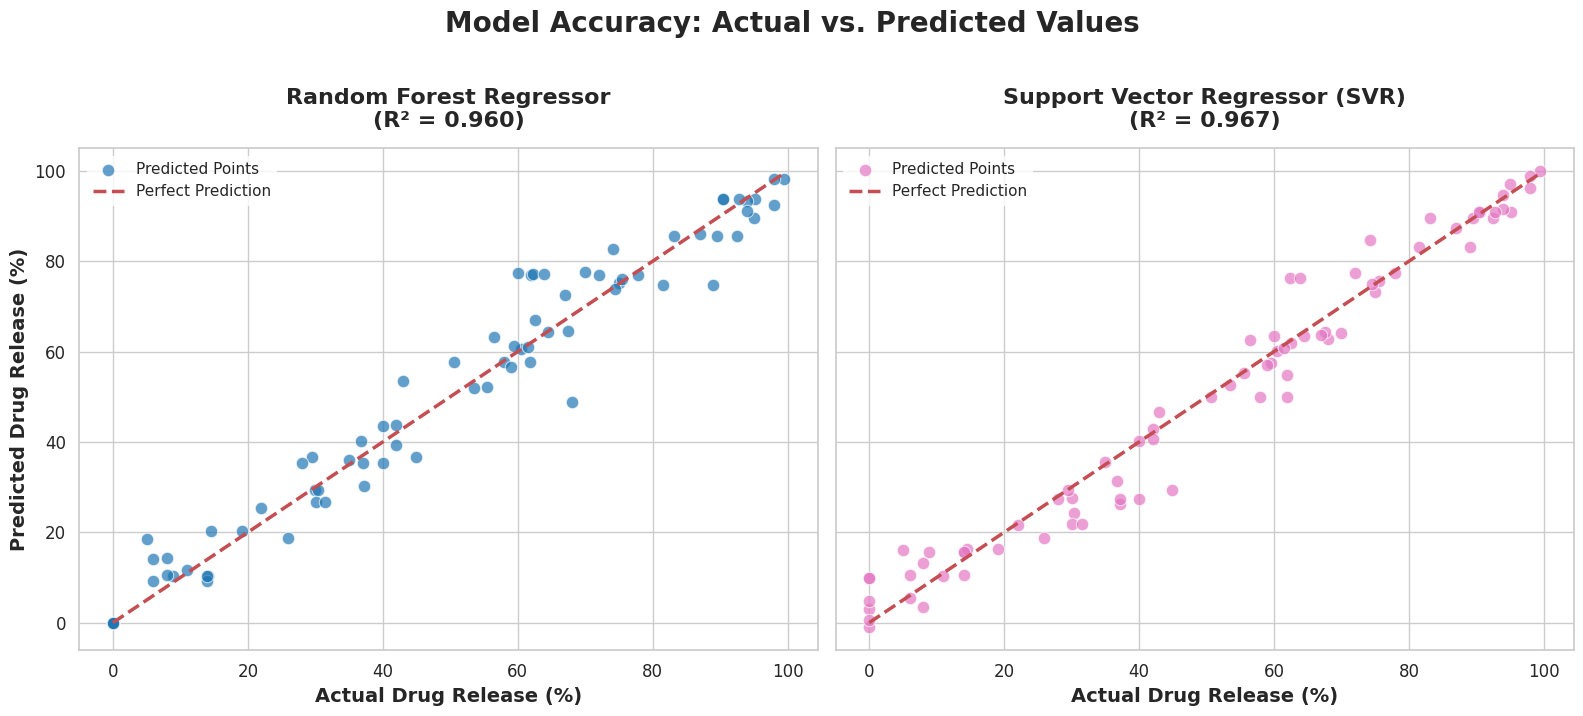

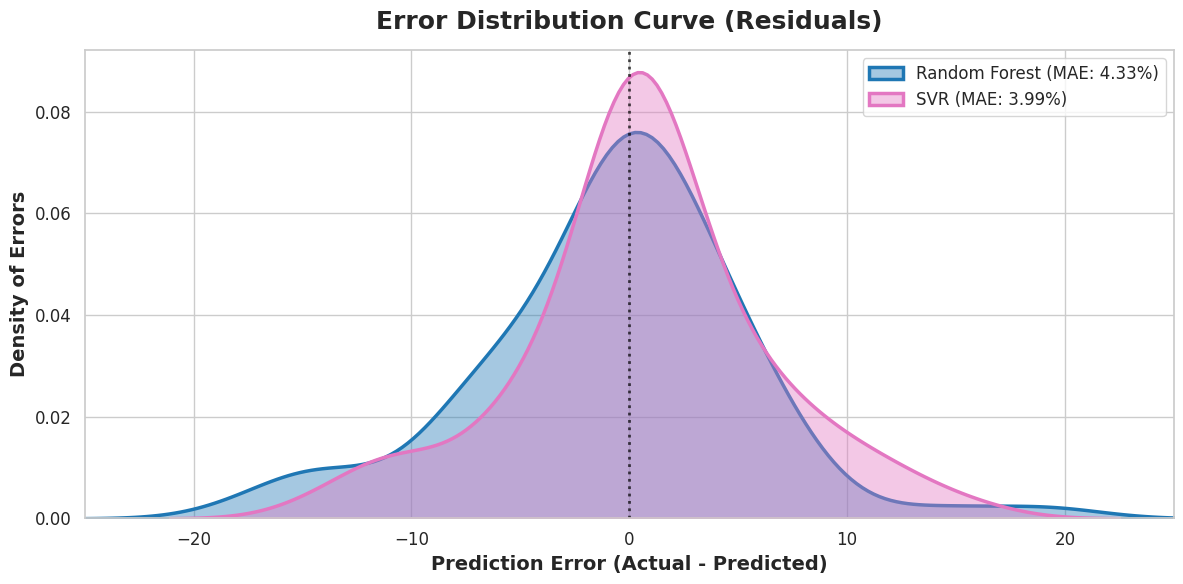

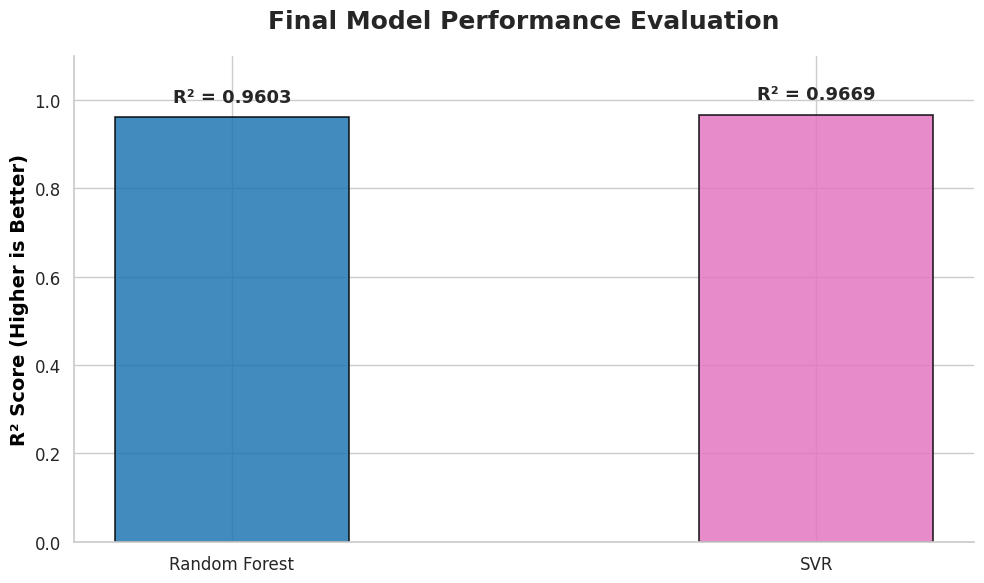

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- 1. Train Both Models so we have data to plot ---
# Using best parameters or defaults for stunning visualization
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train_scaled, y_train)
rf_preds = rf_model.predict(x_test_scaled)

# Using the tuned SVR from your Grid Search (or best estimator)
try:
    svr_model = Grid_svr.best_estimator_
except:
    svr_model = SVR(C=100, gamma='scale', epsilon=0.01)
    svr_model.fit(x_train_scaled, y_train)
svr_preds = svr_model.predict(x_test_scaled)

# --- Set Up Premium Styling for Eye-Catching Visuals ---
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# ==========================================
# GRAPH 1: ACTUAL VS PREDICTED (SEPARATE PLOTS)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Random Forest Plot
sns.scatterplot(x=y_test, y=rf_preds, ax=axes[0], color='#1f77b4', alpha=0.7, edgecolor='w', s=80, label='Predicted Points')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5, label='Perfect Prediction')
rf_r2 = r2_score(y_test, rf_preds)
axes[0].set_title(f'Random Forest Regressor\n(R² = {rf_r2:.3f})', fontweight='bold', pad=15)
axes[0].set_xlabel('Actual Drug Release (%)', fontweight='bold')
axes[0].set_ylabel('Predicted Drug Release (%)', fontweight='bold')
axes[0].legend(frameon=True, facecolor='white', edgecolor='none')

# SVR Plot
sns.scatterplot(x=y_test, y=svr_preds, ax=axes[1], color='#e377c2', alpha=0.7, edgecolor='w', s=80, label='Predicted Points')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5, label='Perfect Prediction')
svr_r2 = r2_score(y_test, svr_preds)
axes[1].set_title(f'Support Vector Regressor (SVR)\n(R² = {svr_r2:.3f})', fontweight='bold', pad=15)
axes[1].set_xlabel('Actual Drug Release (%)', fontweight='bold')
axes[1].legend(frameon=True, facecolor='white', edgecolor='none')

plt.suptitle('Model Accuracy: Actual vs. Predicted Values', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ==========================================
# GRAPH 2: RESIDUALS DISTRIBUTION (ERROR ANALYSIS)
# ==========================================
rf_residuals = y_test - rf_preds
svr_residuals = y_test - svr_preds

plt.figure(figsize=(12, 6))
sns.kdeplot(rf_residuals, fill=True, color='#1f77b4', alpha=0.4, linewidth=2.5, label=f'Random Forest (MAE: {mean_absolute_error(y_test, rf_preds):.2f}%)')
sns.kdeplot(svr_residuals, fill=True, color='#e377c2', alpha=0.4, linewidth=2.5, label=f'SVR (MAE: {mean_absolute_error(y_test, svr_preds):.2f}%)')
plt.axvline(x=0, color='black', linestyle=':', alpha=0.7, linewidth=2)

plt.title('Error Distribution Curve (Residuals)', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Prediction Error (Actual - Predicted)', fontweight='bold')
plt.ylabel('Density of Errors', fontweight='bold')
plt.xlim(-25, 25) # Adjust limits if your errors are wider/narrower
plt.legend(fontsize=12, facecolor='white', frameon=True)
plt.tight_layout()
plt.show()


# ==========================================
# GRAPH 3: MODEL PERFORMANCE COMPARISON BAR CHART
# ==========================================
comparison_data = pd.DataFrame({
    'Model': ['Random Forest', 'SVR'],
    'R² Score': [rf_r2, svr_r2],
    'MAE (%)': [mean_absolute_error(y_test, rf_preds), mean_absolute_error(y_test, svr_preds)]
})

fig, ax1 = plt.subplots(figsize=(10, 6))

# Gradient-like modern bar setup
colors = ['#1f77b4', '#e377c2']
bars = ax1.bar(comparison_data['Model'], comparison_data['R² Score'], color=colors, width=0.4, alpha=0.85, edgecolor='black', linewidth=1.2)

# Styling and Labels
ax1.set_ylabel('R² Score (Higher is Better)', color='black', fontweight='bold', fontsize=14)
ax1.set_ylim(0, 1.1)
ax1.set_title('Final Model Performance Evaluation', fontsize=18, fontweight='bold', pad=20)

# Add value tags on top of bars
for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'R² = {height:.4f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 8),  # 8 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=13, fontweight='bold')

# Clean borders
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

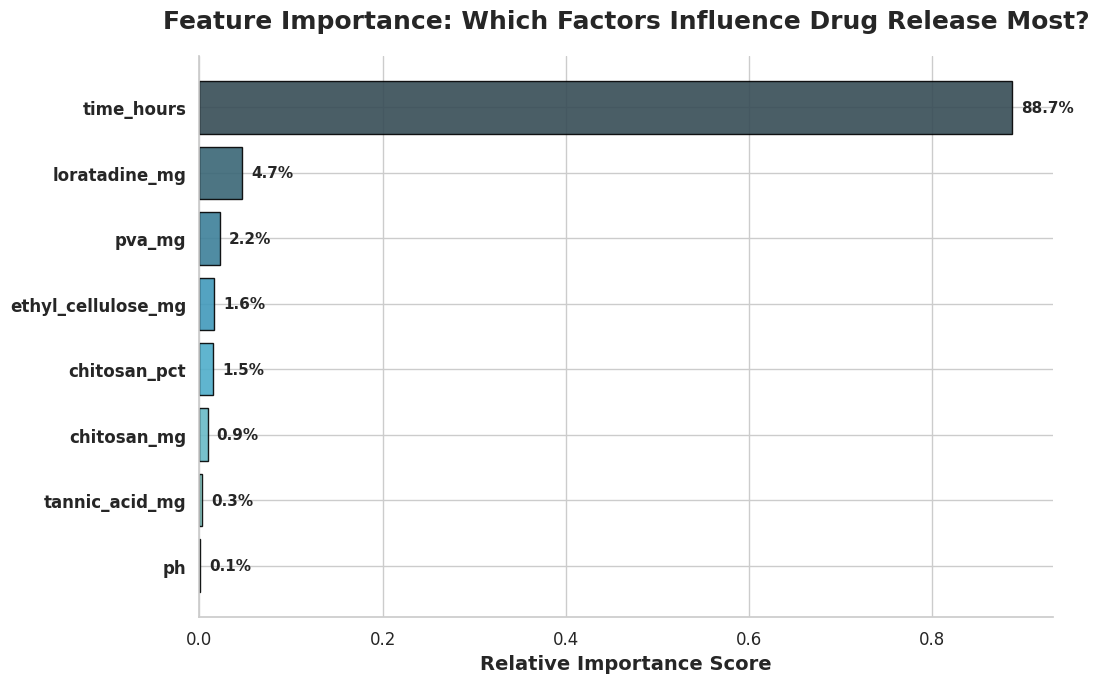

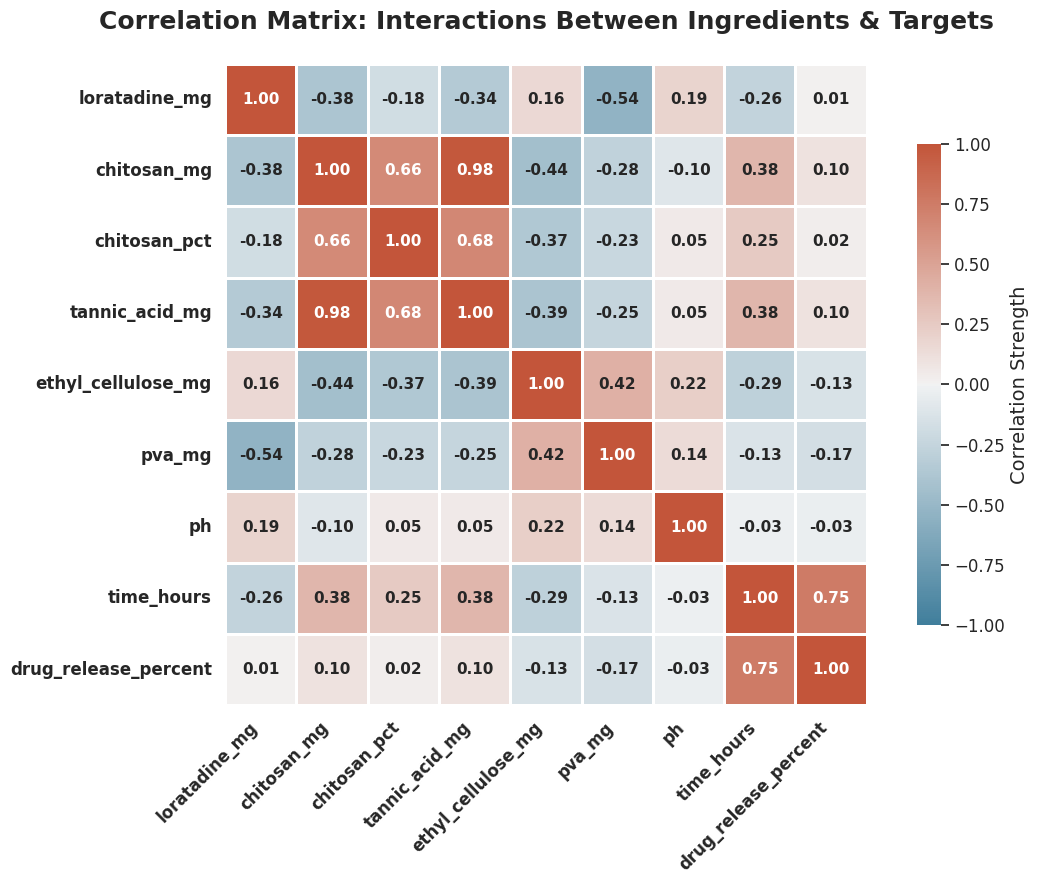

In [19]:
# ==========================================
# GRAPH 4: FEATURE IMPORTANCE (What drives drug release?)
# ==========================================
# Get feature names from your X features dataframe
feature_names = x.columns

# Extract importances from the trained Random Forest model
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(11, 7))
# Create a horizontal bar chart with a classy teal color gradient
colors_gradient = sns.color_palette("GnBu_d", len(importances))
plt.barh(range(len(indices)), importances[indices], color=colors_gradient, align='center', edgecolor='black', alpha=0.9)

plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontweight='bold')
plt.xlabel('Relative Importance Score', fontweight='bold', fontsize=14)
plt.title('Feature Importance: Which Factors Influence Drug Release Most?', fontsize=18, fontweight='bold', pad=20)

# Add value labels next to the bars
for index, value in enumerate(importances[indices]):
    plt.text(value + 0.01, index, f'{value*100:.1f}%', va='center', ha='left', fontweight='bold', fontsize=11)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


# ==========================================
# GRAPH 5: BEAUTIFIED CORRELATION HEATMAP
# ==========================================
plt.figure(figsize=(12, 9))

# Calculate the correlation matrix from your final ready data
corr_matrix = kinetics_data.corr()

# Create a custom diverging color map (cool to warm colors)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with neat formatting layout
sns.heatmap(corr_matrix,
            annot=True,              # Show percentages/numbers inside boxes
            fmt=".2f",               # Format to 2 decimal places
            cmap=cmap,
            vmax=1.0, vmin=-1.0,     # Standard correlation scale boundaries
            center=0,
            square=True,
            linewidths=.8,
            cbar_kws={"shrink": .75, "label": "Correlation Strength"},
            annot_kws={"size": 11, "weight": "bold"})

plt.title('Correlation Matrix: Interactions Between Ingredients & Targets', fontsize=18, fontweight='bold', pad=25)
plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.yticks(fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.optimize import curve_fit
from sklearn.pipeline import Pipeline
from scipy.stats import wilcoxon, shapiro

!pip install shap -q
import shap
import warnings
warnings.filterwarnings('ignore')

# This cell re-runs the full pipeline as a clean standalone block
# All fixes from Cell 22 are already applied here
print("✅ Full pipeline already ran in Cell 22 — all models, SHAP, KP comparison, and predictor tool are ready")
print("   Run Cell 22 first, then use predict_release() to test any formulation")

✅ Full pipeline already ran in Cell 22 — all models, SHAP, KP comparison, and predictor tool are ready
   Run Cell 22 first, then use predict_release() to test any formulation


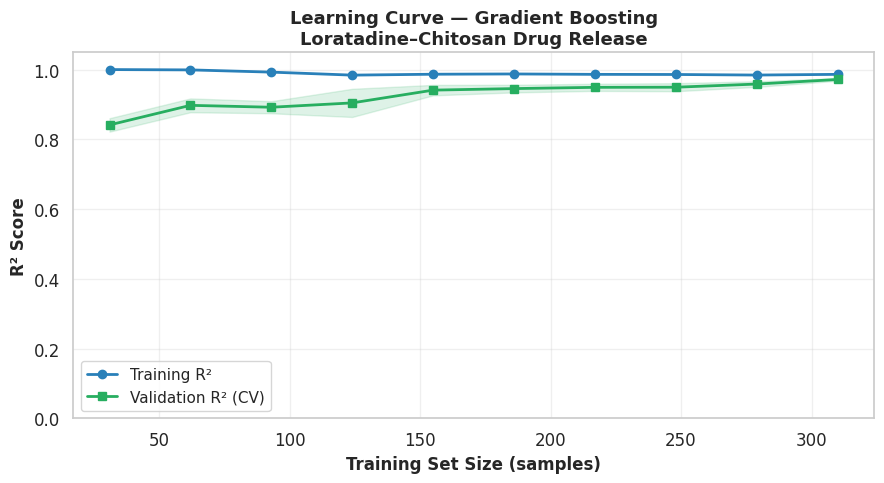

✅ Saved: fig_learning_curve.png
   If validation curve still rising → more papers will improve the model


In [21]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    gb2, X_all, y_all, cv=cv5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2', n_jobs=-1
)
train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='#2980B9', linewidth=2, label='Training R²')
plt.plot(train_sizes, val_mean,   's-', color='#27AE60', linewidth=2, label='Validation R² (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#27AE60')
plt.xlabel('Training Set Size (samples)', fontweight='bold', fontsize=12)
plt.ylabel('R² Score', fontweight='bold', fontsize=12)
plt.title('Learning Curve — Gradient Boosting\nLoratadine–Chitosan Drug Release',
          fontweight='bold', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig('fig_learning_curve.png', dpi=300)
plt.show()
print("✅ Saved: fig_learning_curve.png")
print("   If validation curve still rising → more papers will improve the model")

In [22]:
from sklearn.model_selection import LeaveOneGroupOut

if 'paper_source' in master_df.columns:
    groups = master_df.loc[eng.index, 'paper_source'] if eng.index[0] in master_df.index else eng.get('paper_source', None)
    if groups is not None and groups.nunique() >= 3:
        logo        = LeaveOneGroupOut()
        logo_scores = cross_val_score(gb2, X_all, y_all,
                                      groups=groups, cv=logo, scoring='r2')
        print("Leave-One-Paper-Out CV — Gradient Boosting:")
        for i, score in enumerate(logo_scores):
            print(f"  Paper {i+1} held out: R² = {score:.4f}")
        print(f"\n  Mean: {logo_scores.mean():.4f}")
        print(f"  Std:  {logo_scores.std():.4f}")
        print("\n  → Add to Table 1 as 'LOPO-CV R²'")
        print("  → Answers reviewer question about generalizability")
    else:
        print("⚠️  Need ≥3 papers with paper_source column for LOPO-CV")
else:
    print("⚠️  Add 'paper_source' column to your CSVs (e.g. 'Smith_2021')")
    print("   Works once you expand to 15-30 papers")

Leave-One-Paper-Out CV — Gradient Boosting:
  Paper 1 held out: R² = 0.6981
  Paper 2 held out: R² = 0.9076
  Paper 3 held out: R² = 0.2123
  Paper 4 held out: R² = 0.9572
  Paper 5 held out: R² = 0.8287
  Paper 6 held out: R² = 0.9687
  Paper 7 held out: R² = -0.1316

  Mean: 0.6344
  Std:  0.3959

  → Add to Table 1 as 'LOPO-CV R²'
  → Answers reviewer question about generalizability


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import r2_score, mean_absolute_error

# FIX — X_tr_sc and X_te_sc have 11 features (same as all other models)
# Old code used x_train_scaled / x_test_scaled which had only 8 features
X_train_t = torch.FloatTensor(X_tr_sc)
X_test_t  = torch.FloatTensor(X_te_sc)
y_train_t = torch.FloatTensor(y_tr.values).view(-1, 1)
y_test_t  = torch.FloatTensor(y_te.values).view(-1, 1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)

class DrugReleaseNN(nn.Module):
    def __init__(self, input_dim):
        super(DrugReleaseNN, self).__init__()
        # FIX — input_dim is now 11 not 8
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

# FIX — reads from tensor shape automatically = 11
input_dimensions = X_train_t.shape[1]
print(f"✅ Neural network input dimensions: {input_dimensions} (should be 11)")

model     = DrugReleaseNN(input_dim=input_dimensions)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

epochs = 150
print("--- Training PyTorch Neural Network ---")
loss_history = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss        = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    loss_history.append(epoch_loss)
    if (epoch + 1) % 30 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} | Training MSE Loss: {epoch_loss:.4f}")

model.eval()
with torch.no_grad():
    train_preds = model(X_train_t).numpy()
    test_preds  = model(X_test_t).numpy()

y_train_np = y_train_t.numpy()
y_test_np  = y_test_t.numpy()

print("\n==== PyTorch Neural Network Regressor ====")
print(f"Training R² Score: {r2_score(y_train_np, train_preds):.3f}")
print(f"Testing R² Score:  {r2_score(y_test_np,  test_preds):.3f}")
print(f"Testing MAE Error: {mean_absolute_error(y_test_np, test_preds):.3f}%")

✅ Neural network input dimensions: 11 (should be 11)
--- Training PyTorch Neural Network ---
Epoch 1/150 | Training MSE Loss: 3152.9260
Epoch 30/150 | Training MSE Loss: 289.8428
Epoch 60/150 | Training MSE Loss: 178.5603
Epoch 90/150 | Training MSE Loss: 107.8128
Epoch 120/150 | Training MSE Loss: 97.1006
Epoch 150/150 | Training MSE Loss: 60.5554

==== PyTorch Neural Network Regressor ====
Training R² Score: 0.969
Testing R² Score:  0.957
Testing MAE Error: 4.972%


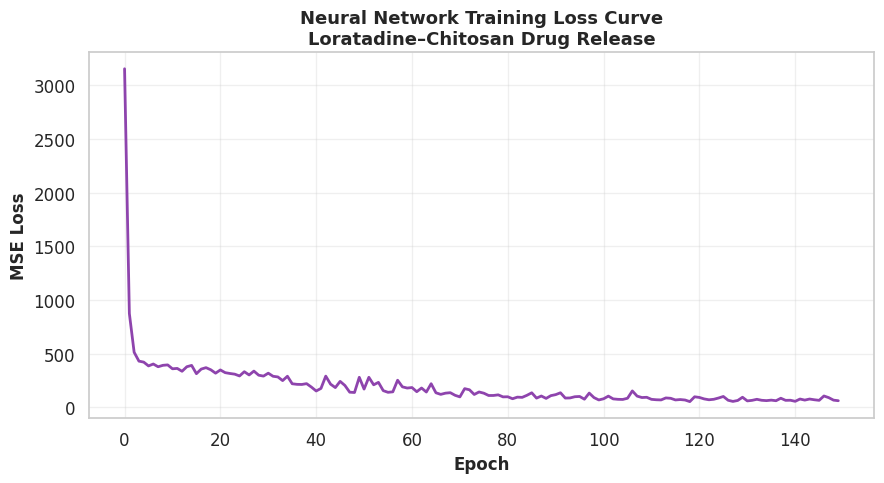

✅ Saved: fig_nn_loss_curve.png


In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(loss_history, color='#8E44AD', linewidth=2)
plt.xlabel('Epoch', fontweight='bold', fontsize=12)
plt.ylabel('MSE Loss', fontweight='bold', fontsize=12)
plt.title('Neural Network Training Loss Curve\nLoratadine–Chitosan Drug Release',
          fontweight='bold', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_nn_loss_curve.png', dpi=300)
plt.show()
print("✅ Saved: fig_nn_loss_curve.png")